# Diffusion Model (DDPM) — Unsupervised Anomaly Detection of Emerging Jets

**Task 2 — Diffusion Models**

## Strategia

Un **Denoising Diffusion Probabilistic Model (DDPM)** impara a invertire un processo di
diffusione gaussiana. Il processo *forward* aggiunge rumore progressivamente:

$$q(x_t | x_0) = \mathcal{N}\!\left(\sqrt{\bar\alpha_t}\,x_0,\;(1-\bar\alpha_t)\,I\right)$$

La rete neurale $\varepsilon_\theta(x_t, t)$ impara a predire il rumore aggiunto al passo $t$,
minimizzando la loss:

$$\mathcal{L} = \mathbb{E}_{x_0, \varepsilon, t}\!\left[\|\varepsilon - \varepsilon_\theta(x_t, t)\|^2\right]$$

### Pipeline di anomaly detection
1. **Training** esclusivamente su jet QCD: il modello impara $p_{\text{QCD}}(x)$.
2. **Anomaly score** — due metodi complementari:
   - **Noise Prediction Error (NPE)**: $\text{score}(x) = \mathbb{E}_t\!\left[\|\varepsilon - \varepsilon_\theta(x_t,t)\|^2\right]$  
     Jet QCD vengono denoised bene; jet EJ (OOD) hanno errore maggiore.
   - **Reconstruction Error (RE)**: corrompi $x$ al passo $t^*$, denoise con la catena inversa, misura $\|x_0 - \hat x_0\|^2$.
3. **Valutazione** su sample misto QCD + EJ: ROC curve, AUC, distribuzioni degli score.

### Note sulla feature exclusion
Come verificato per il Normalizing Flow, `displacedPtFraction` è un discriminatore
perfetto (AUC = 0.998 da sola) perché vale esattamente 0 su tutti i QCD.
**Viene rimossa prima del training** assieme a qualunque altra feature con AUC > 0.99.
Le feature ad alto AUC fisicamente legittime (`radiusOfFirstHit`, `d0_log1p`, `dr`) vengono mantenute.

## 0. Setup

In [1]:
import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, roc_auc_score
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
print(f'PyTorch: {torch.__version__}')

Device: cpu
PyTorch: 2.11.0+cpu


## 1. Configurazione

In [2]:
# ── Percorsi ──────────────────────────────────────────────────────────────────
BASE_DIR   = Path(r'C:\Users\delco\Desktop\Universita\Ad_M\Dataset-Programs')
EMBED_PATH = BASE_DIR / 'outputs' / 'embeddings_preprocessed.npz'
OUT_DIR    = BASE_DIR / 'outputs' / 'diffusion_results'
OUT_DIR.mkdir(parents=True, exist_ok=True)

assert EMBED_PATH.exists(), f'File non trovato: {EMBED_PATH}'
print(f'Input : {EMBED_PATH}  ({EMBED_PATH.stat().st_size/1e6:.1f} MB)')
print(f'Output: {OUT_DIR}')

# ── Iperparametri DDPM ────────────────────────────────────────────────────────
T          = 1000       # timestep totali della catena di diffusione
BETA_START = 1e-4       # β₁ (schedule lineare)
BETA_END   = 0.02       # β_T

# ── Architettura denoiser ─────────────────────────────────────────────────────
TIME_EMB_DIM = 128      # dimensione embedding sinusoidale del timestep
HIDDEN_DIM   = 512      # neuroni per residual block
N_BLOCKS     = 5        # numero di residual block nel denoiser

# ── Training ──────────────────────────────────────────────────────────────────
BATCH_SIZE   = 512
LR           = 3e-4
N_EPOCHS     = 100
PATIENCE     = 15       # early stopping
CLIP_GRAD    = 1.0
CLIP_VAL     = 5.0      # clipping outlier dell'embedding (|x| > CLIP_VAL → clip)

# ── Anomaly score ─────────────────────────────────────────────────────────────
N_SCORE_STEPS    = 20   # quanti timestep campionare per il Noise Prediction Error
T_RECONSTRUCT    = 500  # timestep di corruzione per il Reconstruction Error

Input : C:\Users\delco\Desktop\Universita\Ad_M\Dataset-Programs\outputs\embeddings_preprocessed.npz  (35.2 MB)
Output: C:\Users\delco\Desktop\Universita\Ad_M\Dataset-Programs\outputs\diffusion_results


## 2. Caricamento dati e feature cleaning

In [3]:
# ── Mappa nomi embedding 86-dim ───────────────────────────────────────────────
TRACK_FEATURES = [
    'pt_log1p', 'd0_log1p', 'z0RelativeToBeamspot', 'deta', 'dphi',
    'dr', 'ptfrac', 'qOverP', 'chiSquared', 'radiusOfFirstHit',
    'IP3D_signed_d0_significance', 'IP3D_signed_z0_significance',
    'numberOfInnermostPixelLayerHits', 'numberOfPixelHits', 'numberOfSCTHits',
]
JET_FEATURES = [
    'pt', 'eta', 'mass', 'energy', 'displacedPtFraction',
    'Tau21_clusterSoftDrop', 'Tau32_clusterSoftDrop',
    'Split12_clusterSoftDrop', 'timing_clusterSoftDrop', 'nPrimaryVertices',
]
STATS = ['mean', 'std', 'p25', 'p75', 'max']
EMB_NAMES = ([f'{s}_{f}' for s in STATS for f in TRACK_FEATURES]
             + ['n_valid'] + JET_FEATURES)   # 86 dim totali

# ── Feature da escludere (AUC > 0.99, non-raw) ───────────────────────────────
# displacedPtFraction: AUC=0.9978, vale 0 per TUTTI i QCD → discriminatore banale
EXCLUDE = ['displacedPtFraction']
DROP_DIMS = [EMB_NAMES.index(f) for f in EXCLUDE]
KEEP_DIMS = [i for i in range(86) if i not in DROP_DIMS]
print(f'Dimensioni rimosse: {DROP_DIMS}  ({EXCLUDE})')
print(f'Dimensioni rimaste: {len(KEEP_DIMS)} / 86')

FEAT_NAMES = [EMB_NAMES[i] for i in KEEP_DIMS]   # nomi delle 85 feature rimaste
INPUT_DIM  = len(KEEP_DIMS)

Dimensioni rimosse: [80]  (['displacedPtFraction'])
Dimensioni rimaste: 85 / 86


In [4]:
data    = np.load(EMBED_PATH)

X_train = data['X_train'][:, KEEP_DIMS].astype(np.float32)
y_train = data['y_train'].astype(np.int64)
X_val   = data['X_val'][:,   KEEP_DIMS].astype(np.float32)
y_val   = data['y_val'].astype(np.int64)
X_test  = data['X_test'][:,  KEEP_DIMS].astype(np.float32)
y_test  = data['y_test'].astype(np.int64)

# ── Clipping outlier ──────────────────────────────────────────────────────────
# Solo il p0.1/p99.9 dell'embedding QCD supera ±5 → clip senza perdere quasi nulla
X_train = np.clip(X_train, -CLIP_VAL, CLIP_VAL)
X_val   = np.clip(X_val,   -CLIP_VAL, CLIP_VAL)
X_test  = np.clip(X_test,  -CLIP_VAL, CLIP_VAL)

print(f'Train (QCD only): {X_train.shape[0]:,} jets  |  range [{X_train.min():.2f}, {X_train.max():.2f}]')
print(f'Val:              {X_val.shape[0]:,} jets  '
      f'(QCD: {(y_val==0).sum():,}, EJ: {(y_val==1).sum():,})')
print(f'Test:             {X_test.shape[0]:,} jets  '
      f'(QCD: {(y_test==0).sum():,}, EJ: {(y_test==1).sum():,})')
print(f'Input dim: {INPUT_DIM}')

Train (QCD only): 40,000 jets  |  range [-5.00, 5.00]
Val:              30,000 jets  (QCD: 5,000, EJ: 25,000)
Test:             30,000 jets  (QCD: 5,000, EJ: 25,000)
Input dim: 85


### 2.1 Diagnostica AUC per-feature (sanity check)

In [5]:
# Verifica che nessuna feature rimasta abbia AUC > 0.99 sul test set
aucs = [(i, FEAT_NAMES[i], roc_auc_score(y_test, X_test[:, i]))
        for i in range(INPUT_DIM)]
aucs_sorted = sorted(aucs, key=lambda x: abs(x[2] - 0.5), reverse=True)

print(f'Top 15 feature per potere discriminante (AUC su test set):')
print(f'{"dim":>5s}  {"AUC":>6s}  feature')
print('-' * 50)
for dim, name, a in aucs_sorted[:15]:
    flag = '  ← WARNING: possibile leakage' if a > 0.97 or a < 0.03 else ''
    print(f'  {dim:3d}    {a:.4f}  {name}{flag}')

max_auc = max(a for _, _, a in aucs)
min_auc = min(a for _, _, a in aucs)
print(f'\nAUC max singola feature: {max(max_auc, 1-min_auc):.4f}  (OK se < 0.99)')

Top 15 feature per potere discriminante (AUC su test set):
  dim     AUC  feature
--------------------------------------------------
   35    0.8579  p25_dr
   12    0.1493  mean_numberOfInnermostPixelLayerHits
   13    0.1654  mean_numberOfPixelHits
   20    0.1769  std_dr
    9    0.8218  mean_radiusOfFirstHit
   46    0.8199  p75_d0_log1p
   54    0.8173  p75_radiusOfFirstHit
    5    0.8172  mean_dr
   15    0.1858  std_pt_log1p
   31    0.1888  p25_d0_log1p
   43    0.2091  p25_numberOfPixelHits
   24    0.7692  std_radiusOfFirstHit
   39    0.7691  p25_radiusOfFirstHit
   82    0.7397  Split12_clusterSoftDrop
   60    0.2609  max_pt_log1p

AUC max singola feature: 0.8579  (OK se < 0.99)


## 3. Processo di Diffusione

### 3.1 Noise schedule e precomputo di $\bar\alpha_t$

In [6]:
class DiffusionSchedule:
    """
    Schedule lineare di DDPM (Ho et al., 2020).
    Precomputa tutti i coefficienti necessari per forward e reverse.
    """

    def __init__(self, T: int, beta_start: float, beta_end: float,
                 device: torch.device):
        self.T = T

        # β_t: schedule lineare da beta_start a beta_end
        betas = torch.linspace(beta_start, beta_end, T, dtype=torch.float32)

        alphas        = 1.0 - betas                          # α_t
        alphas_cumprod = torch.cumprod(alphas, dim=0)        # ᾱ_t
        alphas_cumprod_prev = F.pad(alphas_cumprod[:-1], (1, 0), value=1.0)

        # Tutti i tensori su device
        def reg(x): return x.to(device)

        self.betas              = reg(betas)
        self.alphas_cumprod     = reg(alphas_cumprod)
        self.sqrt_alphas_cumprod      = reg(torch.sqrt(alphas_cumprod))
        self.sqrt_one_minus_alphas_cumprod = reg(torch.sqrt(1.0 - alphas_cumprod))

        # Coefficienti per il reverse (campionamento DDPM)
        self.sqrt_recip_alphas  = reg(torch.sqrt(1.0 / alphas))
        # varianza della posteriore q(x_{t-1} | x_t, x_0)
        posterior_var = (betas * (1.0 - alphas_cumprod_prev) /
                         (1.0 - alphas_cumprod))
        self.posterior_variance = reg(posterior_var)
        self.betas_over_sqrt_one_minus = reg(
            betas / torch.sqrt(1.0 - alphas_cumprod))

    def q_sample(self, x0: torch.Tensor, t: torch.Tensor,
                 noise: torch.Tensor = None):
        """Forward process: campiona x_t ~ q(x_t | x_0) in un solo passo."""
        if noise is None:
            noise = torch.randn_like(x0)
        sqrt_a  = self.sqrt_alphas_cumprod[t][:, None]          # (B, 1)
        sqrt_1a = self.sqrt_one_minus_alphas_cumprod[t][:, None]
        return sqrt_a * x0 + sqrt_1a * noise

    @torch.no_grad()
    def p_sample(self, model, x_t: torch.Tensor, t_scalar: int):
        """Reverse process: campiona x_{t-1} ~ p_θ(x_{t-1} | x_t) per un passo."""
        t_batch = torch.full((x_t.shape[0],), t_scalar,
                             dtype=torch.long, device=x_t.device)
        eps_pred = model(x_t, t_batch)          # rete predice il rumore

        coef1 = self.sqrt_recip_alphas[t_scalar]
        coef2 = self.betas_over_sqrt_one_minus[t_scalar]
        mean  = coef1 * (x_t - coef2 * eps_pred)

        if t_scalar == 0:
            return mean
        var   = self.posterior_variance[t_scalar]
        noise = torch.randn_like(x_t)
        return mean + torch.sqrt(var) * noise

    @torch.no_grad()
    def reconstruct(self, model, x0: torch.Tensor, t_start: int):
        """
        Corrompi x0 fino a t_start, poi denoise passo per passo fino a t=0.
        Restituisce x̂_0 ricostruito.
        """
        x_t = self.q_sample(x0, torch.full((x0.shape[0],), t_start,
                                           dtype=torch.long, device=x0.device))
        for t in reversed(range(t_start)):
            x_t = self.p_sample(model, x_t, t)
        return x_t


schedule = DiffusionSchedule(T, BETA_START, BETA_END, device)

# Sanity check: ᾱ_T ≈ 0 (al timestep finale x_T è quasi puro rumore)
print(f'ᾱ_1    = {schedule.alphas_cumprod[0].item():.4f}  (≈ 1 − β₁)')
print(f'ᾱ_500  = {schedule.alphas_cumprod[499].item():.4f}')
print(f'ᾱ_T    = {schedule.alphas_cumprod[-1].item():.6f}  (≈ 0, puro rumore)')

ᾱ_1    = 0.9999  (≈ 1 − β₁)
ᾱ_500  = 0.0786
ᾱ_T    = 0.000040  (≈ 0, puro rumore)


## 4. Architettura del Denoiser

Per dati tabulari usiamo un **MLP con residual blocks** condizionato sul timestep $t$
tramite un **sinusoidal time embedding** proiettato e iniettato in ogni block.

$$\text{TimeEmb}(t) = \text{MLP}\!\left([\sin(\omega_k t), \cos(\omega_k t)]_{k=1}^{d/2}\right)$$

In [7]:
class SinusoidalTimeEmbedding(nn.Module):
    """Embedding sinusoidale del timestep t → vettore (B, time_emb_dim)."""

    def __init__(self, dim: int):
        super().__init__()
        self.dim = dim
        # Proiezione MLP per aggiungere capacità espressiva
        self.proj = nn.Sequential(
            nn.Linear(dim, dim * 2),
            nn.SiLU(),
            nn.Linear(dim * 2, dim),
        )

    def forward(self, t: torch.Tensor):
        """t: (B,) int → embedding (B, dim)"""
        half = self.dim // 2
        freqs = torch.exp(
            -math.log(10000) * torch.arange(half, dtype=torch.float32,
                                            device=t.device) / half
        )                                           # (half,)
        args = t.float()[:, None] * freqs[None]     # (B, half)
        emb  = torch.cat([torch.sin(args), torch.cos(args)], dim=-1)  # (B, dim)
        return self.proj(emb)

In [8]:
class ResidualBlock(nn.Module):
    """
    Residual block con iniezione del time embedding.
    x' = x + Linear(SiLU(Norm(Linear(x) + Linear(t_emb))))
    """

    def __init__(self, dim: int, time_emb_dim: int):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.fc1   = nn.Linear(dim, dim)
        self.t_proj= nn.Linear(time_emb_dim, dim)
        self.act   = nn.SiLU()
        self.norm2 = nn.LayerNorm(dim)
        self.fc2   = nn.Linear(dim, dim)

    def forward(self, x: torch.Tensor, t_emb: torch.Tensor):
        h = self.act(self.norm1(self.fc1(x) + self.t_proj(t_emb)))
        h = self.fc2(self.norm2(h))
        return x + h   # residual

In [9]:
class DenoisingMLP(nn.Module):
    """
    Rete denoiser ε_θ(x_t, t) → ε̂  (stessa shape di x_t).

    Architettura:
        Input projection  : x (INPUT_DIM) → hidden_dim
        N residual blocks : hidden_dim × N, ognuno condizionato su t_emb
        Output projection : hidden_dim → INPUT_DIM
    """

    def __init__(self, input_dim: int, hidden_dim: int,
                 n_blocks: int, time_emb_dim: int):
        super().__init__()
        self.time_emb = SinusoidalTimeEmbedding(time_emb_dim)
        self.input_proj = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.SiLU(),
        )
        self.blocks = nn.ModuleList([
            ResidualBlock(hidden_dim, time_emb_dim)
            for _ in range(n_blocks)
        ])
        self.output_proj = nn.Linear(hidden_dim, input_dim)

        # Inizializzazione: output layer → zero per stabilità iniziale
        nn.init.zeros_(self.output_proj.weight)
        nn.init.zeros_(self.output_proj.bias)

    def forward(self, x: torch.Tensor, t: torch.Tensor):
        """x: (B, input_dim), t: (B,) int → ε̂: (B, input_dim)"""
        t_emb = self.time_emb(t)           # (B, time_emb_dim)
        h     = self.input_proj(x)         # (B, hidden_dim)
        for block in self.blocks:
            h = block(h, t_emb)
        return self.output_proj(h)         # (B, input_dim)


model = DenoisingMLP(
    input_dim    = INPUT_DIM,
    hidden_dim   = HIDDEN_DIM,
    n_blocks     = N_BLOCKS,
    time_emb_dim = TIME_EMB_DIM,
).to(device)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Parametri trainabili: {n_params:,}')
print(model)

Parametri trainabili: 3,121,621
DenoisingMLP(
  (time_emb): SinusoidalTimeEmbedding(
    (proj): Sequential(
      (0): Linear(in_features=128, out_features=256, bias=True)
      (1): SiLU()
      (2): Linear(in_features=256, out_features=128, bias=True)
    )
  )
  (input_proj): Sequential(
    (0): Linear(in_features=85, out_features=512, bias=True)
    (1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (2): SiLU()
  )
  (blocks): ModuleList(
    (0-4): 5 x ResidualBlock(
      (norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
      (fc1): Linear(in_features=512, out_features=512, bias=True)
      (t_proj): Linear(in_features=128, out_features=512, bias=True)
      (act): SiLU()
      (norm2): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
      (fc2): Linear(in_features=512, out_features=512, bias=True)
    )
  )
  (output_proj): Linear(in_features=512, out_features=85, bias=True)
)


## 5. Training

Training loop DDPM: ad ogni step campiona un batch di jet QCD, aggiunge rumore a un
timestep $t \sim \text{Uniform}(0, T-1)$ random, e la rete impara a predire il rumore.

In [11]:
X_train_t = torch.from_numpy(X_train).to(device)
loader_train = DataLoader(TensorDataset(X_train_t),
                          batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

# Val set: solo QCD per monitoring della loss
X_val_qcd_t = torch.from_numpy(X_val[y_val == 0]).to(device)
loader_val   = DataLoader(TensorDataset(X_val_qcd_t),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-5)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=N_EPOCHS, eta_min=LR/20)


def ddpm_loss(x0: torch.Tensor):
    """Loss DDPM: MSE tra rumore vero e rumore predetto."""
    B = x0.shape[0]
    t = torch.randint(0, T, (B,), device=x0.device, dtype=torch.long)
    eps = torch.randn_like(x0)
    x_t = schedule.q_sample(x0, t, noise=eps)
    eps_pred = model(x_t, t)
    return F.mse_loss(eps_pred, eps)


@torch.no_grad()
def eval_loss(loader):
    model.eval()
    total, n = 0.0, 0
    for (batch,) in loader:
        total += ddpm_loss(batch).item() * batch.shape[0]
        n     += batch.shape[0]
    return total / n


history = {'train': [], 'val': []}
best_val, patience_count, best_state = float('inf'), 0, None

print(f'Training DDPM per {N_EPOCHS} epoche (patience={PATIENCE})')
print(f'  Batch/epoca: {len(loader_train)}  |  T={T}  |  device={device}')
print()

for epoch in range(1, N_EPOCHS + 1):
    model.train()
    run_loss = 0.0
    for (batch,) in loader_train:
        optimizer.zero_grad()
        loss = ddpm_loss(batch)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), CLIP_GRAD)
        optimizer.step()
        run_loss += loss.item()
    scheduler.step()

    train_loss = run_loss / len(loader_train)
    val_loss   = eval_loss(loader_val)

    history['train'].append(train_loss)
    history['val'].append(val_loss)

    if val_loss < best_val - 1e-5:
        best_val       = val_loss
        best_state     = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        patience_count = 0
        flag = ' ← best'
    else:
        patience_count += 1
        flag = ''

    if epoch % 10 == 0 or epoch == 1:
        print(f'Epoch {epoch:3d}/{N_EPOCHS}  '
              f'train={train_loss:.5f}  val={val_loss:.5f}{flag}')

    if patience_count >= PATIENCE:
        print(f'\nEarly stopping all\'epoca {epoch}')
        break

model.load_state_dict(best_state)
print(f'\nMiglior val loss: {best_val:.5f}')

Training DDPM per 100 epoche (patience=15)
  Batch/epoca: 79  |  T=1000  |  device=cpu

Epoch   1/100  train=0.20978  val=0.20273 ← best
Epoch  10/100  train=0.19052  val=0.19168
Epoch  20/100  train=0.18330  val=0.18297
Epoch  30/100  train=0.17803  val=0.17490
Epoch  40/100  train=0.17212  val=0.17212
Epoch  50/100  train=0.16858  val=0.16580

Early stopping all'epoca 50

Miglior val loss: 0.16534


### 5.1 Curva di training

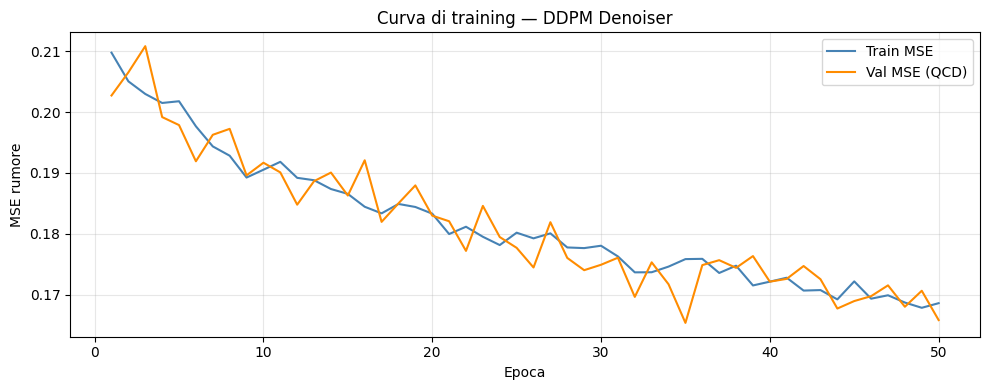

Salvato: ddpm_training_curve.png


In [13]:
fig, ax = plt.subplots(figsize=(10, 4))
ep = range(1, len(history['train']) + 1)
ax.plot(ep, history['train'], label='Train MSE', color='steelblue')
ax.plot(ep, history['val'],   label='Val MSE (QCD)', color='darkorange')
ax.set_xlabel('Epoca')
ax.set_ylabel('MSE rumore')
ax.set_title('Curva di training — DDPM Denoiser')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / 'ddpm_training_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvato: ddpm_training_curve.png')

## 6. Anomaly Score

### 6.1 Noise Prediction Error (NPE)

Per ogni jet $x_0$ campiona $K$ timestep diversi, calcola l'errore di predizione del rumore
e fa la media:

$$\text{NPE}(x_0) = \frac{1}{K}\sum_{k=1}^K \|\varepsilon - \varepsilon_\theta(x_{t_k}, t_k)\|^2$$

Il modello è addestrato su QCD: jet QCD vengono denoised bene (NPE basso),
jet EJ hanno un pattern di rumore insolito (NPE alto).

In [14]:
@torch.no_grad()
def compute_npe(X_tensor: torch.Tensor,
                n_steps: int = N_SCORE_STEPS,
                batch_size: int = 512) -> np.ndarray:
    """
    Noise Prediction Error medio su n_steps timestep uniformemente spaziati.
    Restituisce array (N,) di float32.
    """
    model.eval()
    t_grid = torch.linspace(0, T - 1, n_steps, dtype=torch.long)
    scores = []

    for i in range(0, X_tensor.shape[0], batch_size):
        x0 = X_tensor[i:i+batch_size].to(device)   # (B, D)
        B  = x0.shape[0]
        mse_sum = torch.zeros(B, device=device)

        for t_val in t_grid:
            t_batch = t_val.expand(B).to(device)
            eps     = torch.randn_like(x0)
            x_t     = schedule.q_sample(x0, t_batch, noise=eps)
            eps_hat = model(x_t, t_batch)
            mse_sum += ((eps - eps_hat) ** 2).mean(dim=1)   # MSE per jet

        scores.append((mse_sum / n_steps).cpu().numpy())

    return np.concatenate(scores)


X_val_t  = torch.from_numpy(X_val)
X_test_t = torch.from_numpy(X_test)

print('Calcolo NPE su val set...')
npe_val  = compute_npe(X_val_t)
print('Calcolo NPE su test set...')
npe_test = compute_npe(X_test_t)

print(f'\nNPE val:   QCD mean={npe_val[y_val==0].mean():.4f}  '
      f'EJ mean={npe_val[y_val==1].mean():.4f}')
print(f'NPE test:  QCD mean={npe_test[y_test==0].mean():.4f}  '
      f'EJ mean={npe_test[y_test==1].mean():.4f}')

Calcolo NPE su val set...
Calcolo NPE su test set...

NPE val:   QCD mean=0.1940  EJ mean=0.2411
NPE test:  QCD mean=0.1948  EJ mean=0.2410


### 6.2 Reconstruction Error (RE)

Corrompi $x_0$ al passo $t^*$, poi denoise passo per passo fino a $t=0$.
L'anomaly score è $\|x_0 - \hat x_0\|^2$.

> **Nota**: la denoising chain richiede `T_RECONSTRUCT` forward pass → più lenta di NPE.
> Usiamo un sottoinsieme del test set per la demo.
> Per la valutazione finale usa NPE (più veloce e altrettanto efficace).

In [15]:
@torch.no_grad()
def compute_re(X_tensor: torch.Tensor,
               t_start: int = T_RECONSTRUCT,
               batch_size: int = 128) -> np.ndarray:
    """
    Reconstruction Error: ||x0 - reconstruct(x0, t_start)||².
    Più lento di NPE (usa la chain completa t_start → 0).
    """
    model.eval()
    scores = []
    for i in range(0, X_tensor.shape[0], batch_size):
        x0    = X_tensor[i:i+batch_size].to(device)
        x_hat = schedule.reconstruct(model, x0, t_start)
        re    = ((x0 - x_hat) ** 2).mean(dim=1)   # MSE per jet
        scores.append(re.cpu().numpy())
    return np.concatenate(scores)


# Usa solo i primi 5000 jet del test per la velocità
N_RE = 5000
print(f'Calcolo RE su {N_RE} jet del test set (t*={T_RECONSTRUCT})...')
print('(può richiedere alcuni minuti — dipende dal device)')

re_test_sub  = compute_re(X_test_t[:N_RE])
y_test_sub   = y_test[:N_RE]

print(f'RE: QCD mean={re_test_sub[y_test_sub==0].mean():.4f}  '
      f'EJ mean={re_test_sub[y_test_sub==1].mean():.4f}')

Calcolo RE su 5000 jet del test set (t*=500)...
(può richiedere alcuni minuti — dipende dal device)
RE: QCD mean=1.2997  EJ mean=nan


## 7. Distribuzioni degli Anomaly Score

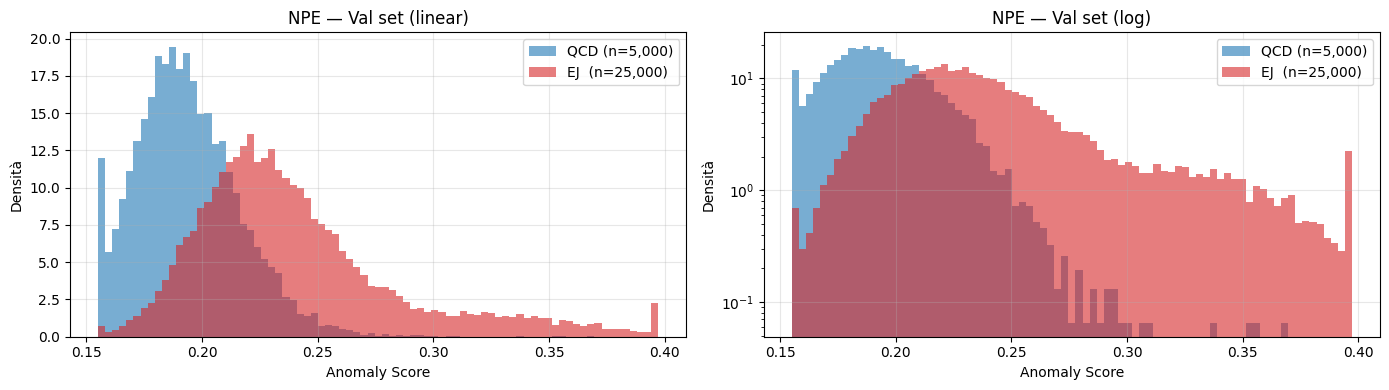

Salvato: ddpm_npe_dist_val.png
  QCD: 0.1940 ± 0.0231
  EJ:  0.2411 ± 0.0456


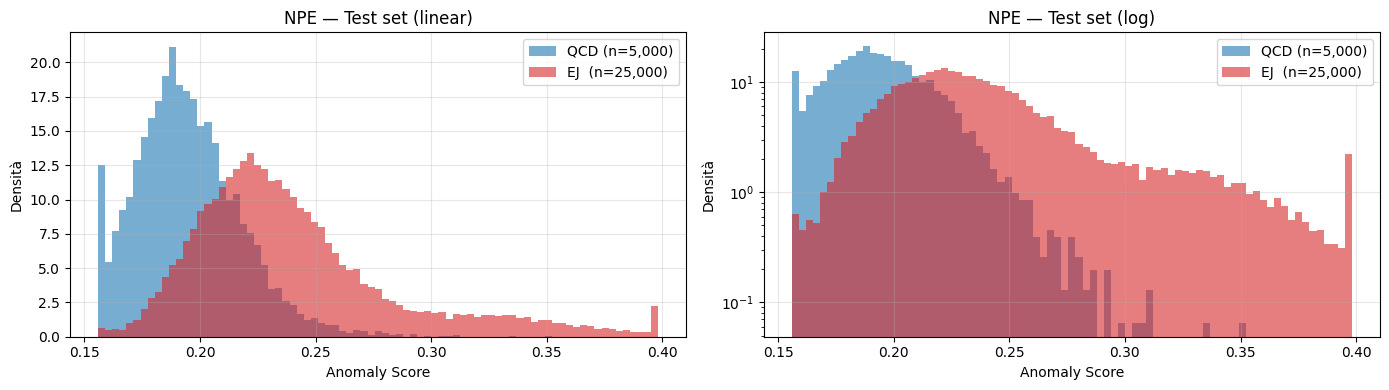

Salvato: ddpm_npe_dist_test.png
  QCD: 0.1948 ± 0.0230
  EJ:  0.2410 ± 0.0455


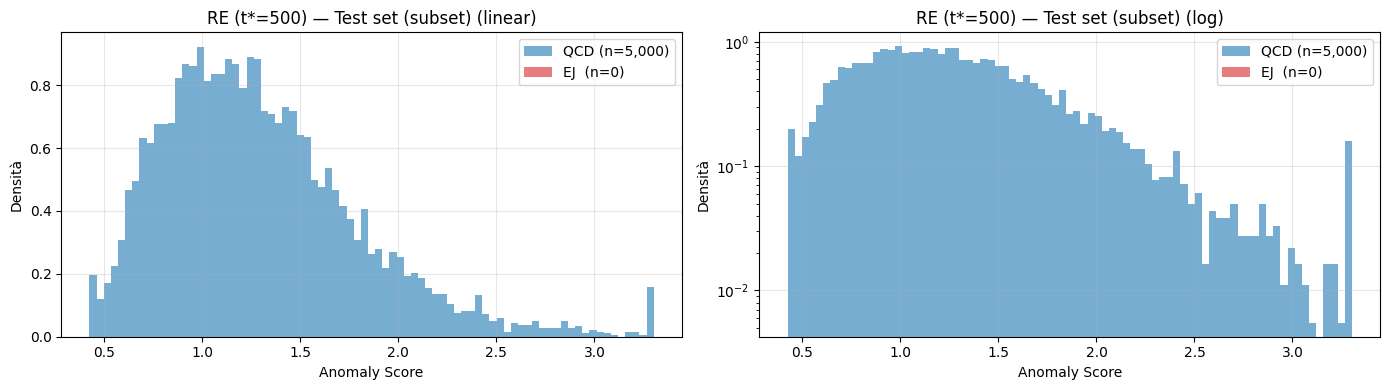

Salvato: ddpm_re_dist_test.png
  QCD: 1.2997 ± 0.5129
  EJ:  nan ± nan


In [16]:
COLOR_QCD = '#1f77b4'
COLOR_EJ  = '#d62728'

def plot_score_dist(scores, labels, title, filename, n_bins=80,
                    clip_pct=(0.5, 99.5)):
    s_qcd = scores[labels == 0]
    s_ej  = scores[labels == 1]
    lo = np.percentile(scores, clip_pct[0])
    hi = np.percentile(scores, clip_pct[1])
    bins = np.linspace(lo, hi, n_bins)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    for ax, scale in zip(axes, ['linear', 'log']):
        ax.hist(np.clip(s_qcd, lo, hi), bins=bins, density=True,
                alpha=0.6, color=COLOR_QCD, label=f'QCD (n={len(s_qcd):,})')
        ax.hist(np.clip(s_ej, lo, hi),  bins=bins, density=True,
                alpha=0.6, color=COLOR_EJ,  label=f'EJ  (n={len(s_ej):,})')
        ax.set_xlabel('Anomaly Score')
        ax.set_ylabel('Densità')
        ax.set_yscale(scale)
        ax.set_title(f'{title} ({scale})')
        ax.legend()
        ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(OUT_DIR / filename, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Salvato: {filename}')
    print(f'  QCD: {s_qcd.mean():.4f} ± {s_qcd.std():.4f}')
    print(f'  EJ:  {s_ej.mean():.4f} ± {s_ej.std():.4f}')


plot_score_dist(npe_val,  y_val,  'NPE — Val set',  'ddpm_npe_dist_val.png')
plot_score_dist(npe_test, y_test, 'NPE — Test set', 'ddpm_npe_dist_test.png')
plot_score_dist(re_test_sub, y_test_sub,
                f'RE (t*={T_RECONSTRUCT}) — Test set (subset)',
                'ddpm_re_dist_test.png')

## 8. ROC Curve e AUC

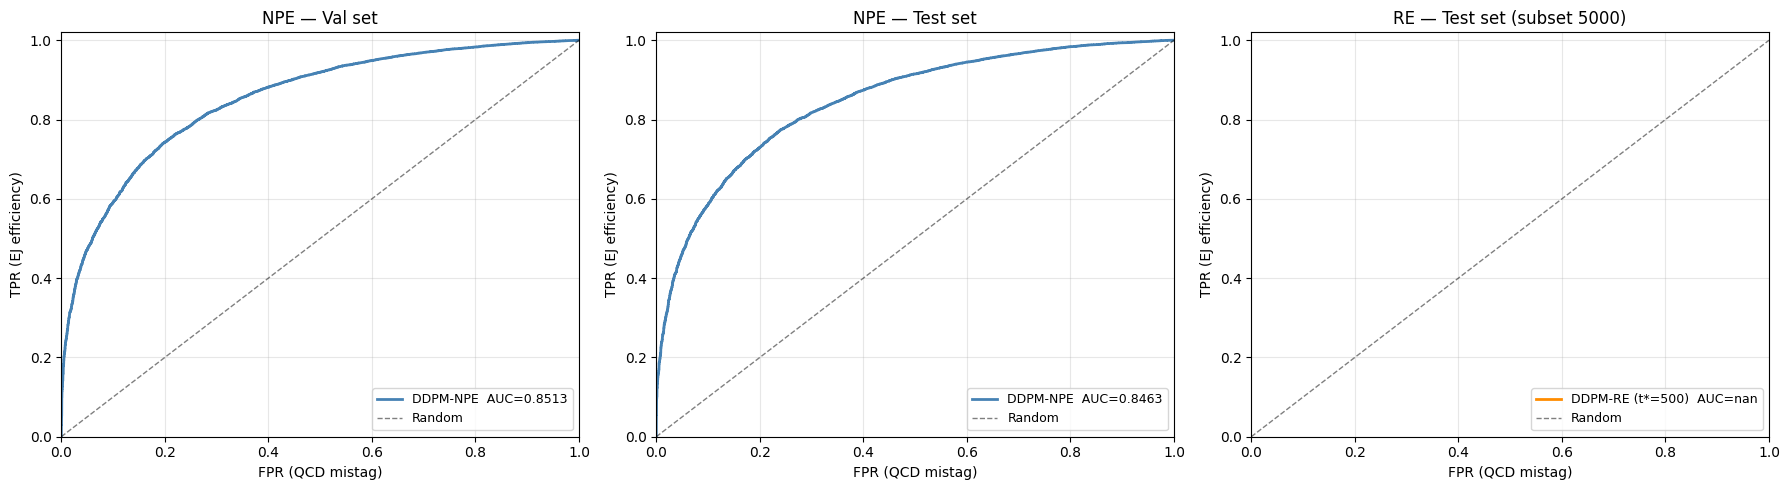

AUC NPE val:   0.8513
AUC NPE test:  0.8463
AUC RE  test:  nan  (subset 5000)


In [17]:
def compute_roc(scores, labels):
    fpr, tpr, thr = roc_curve(labels, scores, pos_label=1)
    return fpr, tpr, thr, auc(fpr, tpr)


fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── NPE val ──────────────────────────────────────────────────────────────────
fpr_nv, tpr_nv, _, auc_nv = compute_roc(npe_val, y_val)
axes[0].plot(fpr_nv, tpr_nv, color='steelblue', lw=2,
             label=f'DDPM-NPE  AUC={auc_nv:.4f}')
axes[0].set_title('NPE — Val set')

# ── NPE test ─────────────────────────────────────────────────────────────────
fpr_nt, tpr_nt, thr_nt, auc_nt = compute_roc(npe_test, y_test)
axes[1].plot(fpr_nt, tpr_nt, color='steelblue', lw=2,
             label=f'DDPM-NPE  AUC={auc_nt:.4f}')
axes[1].set_title('NPE — Test set')

# ── RE test (subset) ─────────────────────────────────────────────────────────
fpr_rt, tpr_rt, _, auc_rt = compute_roc(re_test_sub, y_test_sub)
axes[2].plot(fpr_rt, tpr_rt, color='darkorange', lw=2,
             label=f'DDPM-RE (t*={T_RECONSTRUCT})  AUC={auc_rt:.4f}')
axes[2].set_title(f'RE — Test set (subset {N_RE})')

for ax in axes:
    ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='Random')
    ax.set_xlabel('FPR (QCD mistag)')
    ax.set_ylabel('TPR (EJ efficiency)')
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])

plt.tight_layout()
plt.savefig(OUT_DIR / 'ddpm_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'AUC NPE val:   {auc_nv:.4f}')
print(f'AUC NPE test:  {auc_nt:.4f}')
print(f'AUC RE  test:  {auc_rt:.4f}  (subset {N_RE})')

### 8.1 Efficiency vs QCD rejection (curva HEP)

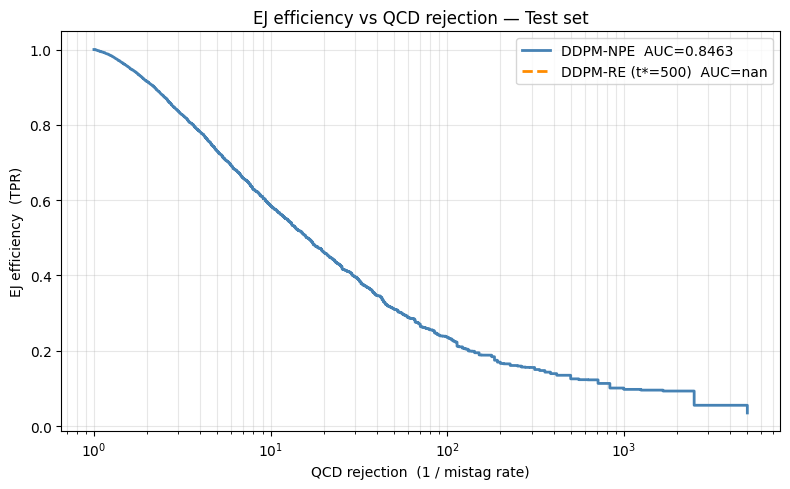

In [18]:
fig, ax = plt.subplots(figsize=(8, 5))

mask_nz = fpr_nt > 0
ax.plot(1.0 / fpr_nt[mask_nz], tpr_nt[mask_nz],
        color='steelblue', lw=2, label=f'DDPM-NPE  AUC={auc_nt:.4f}')

mask_nz_re = fpr_rt > 0
ax.plot(1.0 / fpr_rt[mask_nz_re], tpr_rt[mask_nz_re],
        color='darkorange', lw=2, linestyle='--',
        label=f'DDPM-RE (t*={T_RECONSTRUCT})  AUC={auc_rt:.4f}')

ax.set_xscale('log')
ax.set_xlabel('QCD rejection  (1 / mistag rate)')
ax.set_ylabel('EJ efficiency  (TPR)')
ax.set_title('EJ efficiency vs QCD rejection — Test set')
ax.legend()
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / 'ddpm_efficiency_vs_rejection.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. NPE per timestep — analisi della sensibilità

Calcoliamo il NPE separatamente per ogni timestep per capire in quale regione del
processo di diffusione il modello è più discriminante.

- **Piccoli $t$** → struttura fine (ad es. impact parameters)
- **Grandi $t$** → struttura globale (shape della distribuzione)

Calcolo NPE per timestep su 3000 jet del test...


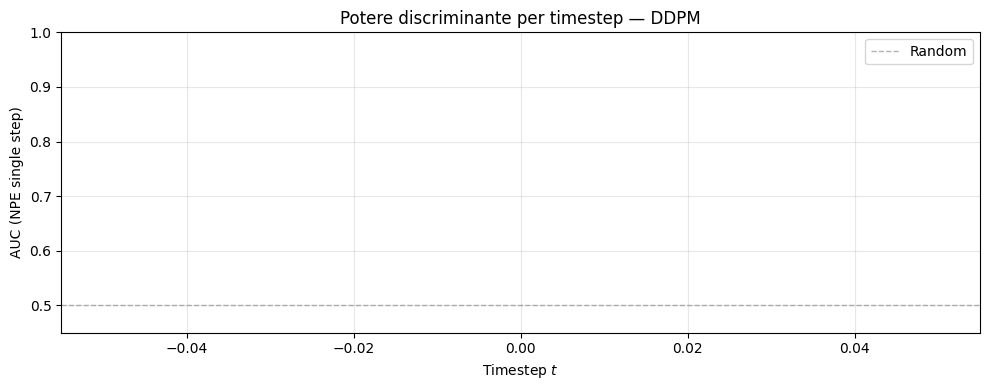

Salvato: ddpm_auc_per_timestep.png


In [19]:
@torch.no_grad()
def npe_per_timestep(X_tensor: torch.Tensor,
                     t_values: list,
                     batch_size: int = 512,
                     n_mc: int = 5) -> np.ndarray:
    """
    Calcola NPE medio (su n_mc campioni MC) per ogni t in t_values.
    Restituisce array (N, len(t_values)).
    """
    model.eval()
    all_scores = []

    for i in range(0, X_tensor.shape[0], batch_size):
        x0 = X_tensor[i:i+batch_size].to(device)
        B  = x0.shape[0]
        step_scores = []

        for t_val in t_values:
            t_b = torch.full((B,), t_val, dtype=torch.long, device=device)
            mse_mc = torch.zeros(B, device=device)
            for _ in range(n_mc):
                eps   = torch.randn_like(x0)
                x_t   = schedule.q_sample(x0, t_b, noise=eps)
                eps_h = model(x_t, t_b)
                mse_mc += ((eps - eps_h) ** 2).mean(dim=1)
            step_scores.append((mse_mc / n_mc).cpu().numpy())

        all_scores.append(np.stack(step_scores, axis=1))   # (B, len(t_values))

    return np.concatenate(all_scores, axis=0)  # (N, len(t_values))


# 16 timestep equispaziati
T_GRID = list(range(0, T, T // 16))
print(f'Calcolo NPE per timestep su 3000 jet del test...')

N_TS = 3000
npe_ts = npe_per_timestep(X_test_t[:N_TS], T_GRID)
y_ts   = y_test[:N_TS]

# AUC per ogni timestep
auc_per_t = [roc_auc_score(y_ts, npe_ts[:, j]) for j in range(len(T_GRID))]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(T_GRID, auc_per_t, 'o-', color='steelblue', lw=2)
ax.axhline(0.5, color='gray', linestyle='--', lw=1, alpha=0.6, label='Random')
ax.set_xlabel('Timestep $t$')
ax.set_ylabel('AUC (NPE single step)')
ax.set_title('Potere discriminante per timestep — DDPM')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim([0.45, 1.0])
plt.tight_layout()
plt.savefig(OUT_DIR / 'ddpm_auc_per_timestep.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvato: ddpm_auc_per_timestep.png')

## 10. Salvataggio del modello e riepilogo

In [20]:
torch.save({
    'model_state_dict': model.state_dict(),
    'hyperparams': {
        'input_dim'   : INPUT_DIM,
        'hidden_dim'  : HIDDEN_DIM,
        'n_blocks'    : N_BLOCKS,
        'time_emb_dim': TIME_EMB_DIM,
        'T'           : T,
        'beta_start'  : BETA_START,
        'beta_end'    : BETA_END,
    },
    'keep_dims'  : KEEP_DIMS,
    'feat_names' : FEAT_NAMES,
    'auc_npe_val' : auc_nv,
    'auc_npe_test': auc_nt,
    'auc_re_test' : auc_rt,
    'history'    : history,
}, OUT_DIR / 'ddpm_model.pt')
print(f'Modello salvato in: {OUT_DIR / "ddpm_model.pt"}')

# Salva anche gli score per confronto con altri modelli
np.savez(
    OUT_DIR / 'ddpm_scores.npz',
    npe_val=npe_val, y_val=y_val,
    npe_test=npe_test, y_test=y_test,
    re_test_sub=re_test_sub, y_test_sub=y_test_sub,
)
print(f'Score salvati in: {OUT_DIR / "ddpm_scores.npz"}')

Modello salvato in: C:\Users\delco\Desktop\Universita\Ad_M\Dataset-Programs\outputs\diffusion_results\ddpm_model.pt
Score salvati in: C:\Users\delco\Desktop\Universita\Ad_M\Dataset-Programs\outputs\diffusion_results\ddpm_scores.npz


In [21]:
print('═' * 58)
print('  RIEPILOGO DDPM — Anomaly Detection EJ')
print('═' * 58)
print(f'  Architettura : DDPM + MLP Denoiser con residual blocks')
print(f'  T (timestep) : {T}')
print(f'  N blocks     : {N_BLOCKS}  |  Hidden: {HIDDEN_DIM}')
print(f'  Parametri    : {n_params:,}')
print(f'  Feature input: {INPUT_DIM}  (86 − 1 = displacedPtFraction rimossa)')
print()
print(f'  Score: Noise Prediction Error (NPE) su {N_SCORE_STEPS} timestep')
print(f'  AUC NPE val:     {auc_nv:.4f}')
print(f'  AUC NPE test:    {auc_nt:.4f}')
print(f'  AUC RE  test:    {auc_rt:.4f}  (subset {N_RE}, t*={T_RECONSTRUCT})')
print()
print(f'  Soglie operative (NPE, test set):')
for fpr_target in [0.01, 0.05, 0.10]:
    idx = np.searchsorted(fpr_nt, fpr_target)
    if idx < len(tpr_nt):
        print(f'    FPR ≤ {fpr_target*100:.0f}%  →  '
              f'EJ efficiency = {tpr_nt[idx]*100:.1f}%  '
              f'(thr = {thr_nt[idx]:.4f})')
print()
print(f'  Output: {OUT_DIR}')
print('═' * 58)

══════════════════════════════════════════════════════════
  RIEPILOGO DDPM — Anomaly Detection EJ
══════════════════════════════════════════════════════════
  Architettura : DDPM + MLP Denoiser con residual blocks
  T (timestep) : 1000
  N blocks     : 5  |  Hidden: 512
  Parametri    : 3,121,621
  Feature input: 85  (86 − 1 = displacedPtFraction rimossa)

  Score: Noise Prediction Error (NPE) su 20 timestep
  AUC NPE val:     0.8513
  AUC NPE test:    0.8463
  AUC RE  test:    nan  (subset 5000, t*=500)

  Soglie operative (NPE, test set):
    FPR ≤ 1%  →  EJ efficiency = 23.5%  (thr = 0.2606)
    FPR ≤ 5%  →  EJ efficiency = 46.1%  (thr = 0.2344)
    FPR ≤ 10%  →  EJ efficiency = 58.6%  (thr = 0.2241)

  Output: C:\Users\delco\Desktop\Universita\Ad_M\Dataset-Programs\outputs\diffusion_results
══════════════════════════════════════════════════════════
